# Amazon Review Intelligence — 02. Sentiment Models

What happens in this notebook:
- split the data into train and test sets (80/20, preserving class proportions);
- turn the cleaned text into TF-IDF features;
- train and compare three baseline models: Logistic Regression, LinearSVC, LightGBM;
- build and save the final model for the dashboard (takes raw text, returns sentiment);
- tune LinearSVC hyperparameters and fine-tune a DistilBERT transformer;
- compare all models in one table.

**Input:** `data/reviews_clean.parquet` (created in [notebook 01](01_data_eda.ipynb)).
**Output:** trained models in `models/`; `data/split.parquet` — the saved train/test split so that [notebook 03](03_topics_insights.ipynb) works with the same test set.

---

# Amazon Review Intelligence — 02. Модели тональности

Что происходит в этом ноутбуке:
- делим данные на обучающую и тестовую выборки (80/20, с сохранением пропорций классов);
- превращаем очищенный текст в признаки TF-IDF;
- обучаем и сравниваем три базовые модели: Logistic Regression, LinearSVC, LightGBM;
- собираем и сохраняем финальную модель для дашборда (принимает сырой текст, возвращает тональность);
- подбираем гиперпараметры LinearSVC и дообучаем трансформер DistilBERT;
- сравниваем все модели в одной таблице.

**Вход:** `data/reviews_clean.parquet` (создаётся в [ноутбуке 01](01_data_eda.ipynb)).
**Выход:** обученные модели в `models/`; `data/split.parquet` — сохранённое разбиение train/test, чтобы [ноутбук 03](03_topics_insights.ipynb) работал с той же тестовой выборкой.

In [1]:
# All paths in the project are relative to the repo root (data/, models/):
# the notebook lives in notebooks/, so we move one level up
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

# Imports and environment setup
import joblib


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

# Pipeline, data splitting and hyperparameter search
from scipy.stats import loguniform
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Quality metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# DistilBERT (section 2.4)
import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# Text cleaning shared with the dashboard and notebook 01 (see nlp_utils.py)
from nlp_utils import clean_batch

# Pandas display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Matplotlib plot style
plt.style.use("ggplot")

In [2]:
# Load the dataset prepared in 01_data_eda.ipynb
reviews = pd.read_parquet("data/reviews_clean.parquet")
print(f"Loaded: {reviews.shape}")

Loaded: (460697, 14)


## 2.1 Sentiment Analysis (Baseline Models)

We train three classic models on TF-IDF features and compare them. Sentiment labels (negative / neutral / positive) were created from star ratings in notebook 01.

Обучаем три классические модели на признаках TF-IDF и сравниваем их. Классы тональности (negative / neutral / positive) созданы из звёздных рейтингов в ноутбуке 01.

### Train/test split

We split the data 80/20 with stratification, so both sets keep the same class proportions. The split is fixed (`random_state=42`) and saved to disk — every model in the project is evaluated on the same test set.

Делим данные 80/20 со стратификацией — обе выборки сохраняют пропорции классов. Разбиение зафиксировано (`random_state=42`) и сохраняется на диск: все модели проекта оцениваются на одной и той же тестовой выборке.

In [3]:
# Use the text as the feature and sentiment_label as the target
X = reviews["clean_text"]
y = reviews["sentiment_label"]

print(X.shape)
print(y.shape)

(460697,)
(460697,)


In [4]:
# Check class distribution before splitting
y.value_counts(normalize=True) * 100

sentiment_label
positive    81.726818
negative    11.213010
neutral      7.060172
Name: proportion, dtype: float64

In [5]:
# Split into train and test preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(368557,)
(92140,)


In [6]:
# Save the split to disk: notebook 03 uses exactly this
# test set instead of re-creating it
reviews["split"] = np.where(reviews.index.isin(X_test.index), "test", "train")
reviews[["split"]].to_parquet("data/split.parquet")
print(reviews["split"].value_counts())

split
train    368557
test      92140
Name: count, dtype: int64


In [7]:
# Verify class proportions are preserved in train and test
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)


sentiment_label
positive    81.726843
negative    11.212920
neutral      7.060238
Name: proportion, dtype: float64
sentiment_label
positive    81.726720
negative    11.213371
neutral      7.059909
Name: proportion, dtype: float64


### TF-IDF features

We convert the cleaned text into TF-IDF features using single words and two-word phrases (unigrams and bigrams).

Преобразуем очищенный текст в признаки TF-IDF, используя отдельные слова и пары слов (униграммы и биграммы).

In [8]:
# TF-IDF parameters shared by the pipeline models
TFIDF_PARAMS = dict(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

print("TF-IDF params defined:", TFIDF_PARAMS)

TF-IDF params defined: {'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9}


### Baseline Model 1: Logistic Regression

We train the first baseline classifier and evaluate it with a classification report and a confusion matrix.

Обучаем первый базовый классификатор и оцениваем его по classification report и матрице ошибок.

In [9]:
# Path to the saved model
log_reg_model_path = "models/log_reg_pipeline.joblib"

# Build the pipeline: TF-IDF → Logistic Regression
# Each model trains inside its own pipeline to avoid data leakage

pipe_log_reg = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

# Load the model if it already exists
if os.path.exists(log_reg_model_path):

    pipe_log_reg = joblib.load(
        log_reg_model_path
    )

    print("Logistic Regression model loaded")

# Otherwise train and save
else:

    pipe_log_reg.fit(X_train, y_train)

    joblib.dump(
        pipe_log_reg,
        log_reg_model_path
    )

    print("Logistic Regression model trained and saved")

Logistic Regression model loaded


/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when

In [10]:
# Logistic Regression predictions
y_pred_log_reg = pipe_log_reg.predict(X_test)

# Class probabilities
y_proba_log_reg = pipe_log_reg.predict_proba(X_test)

# Max probability = confidence score
confidence_log_reg = y_proba_log_reg.max(axis=1)

In [11]:
# Prediction table
predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_log_reg,
    "confidence": confidence_log_reg
})

predictions_df.head()

,text,true_label,predicted_label,confidence
0,i love it i bought this because it is pretty and the green one reminds me of my parrot it looks like the picture,positive,positive,0.727524
1,good size cute and durable i originally ordered the goose one liked it so much i ordered the fox it is a perfect sized coffee cup i can put abut 12 1 2 oz coffee or tea in comfortably it has a sle...,positive,positive,0.980840
2,you get what you pay for not that bad though if you just need an extra cover for a guest room or something this is perfect it s cheap and simple but the size is a little larger than it should be b...,neutral,neutral,0.886476
3,wow so much more than i anticipated while this may appear like a fancy update on a beanbag style chair it is so much more than that this low sitting chair will quickly become a favorite for people...,positive,positive,0.936045
4,great no slip treads easy to adhere to a clean surface used alcohol on the surface as implied in instructions have been in place through numerous baths and showers with no problem,positive,positive,0.951010


In [12]:
# Evaluate the model per class
print(classification_report(y_test, y_pred_log_reg))


              precision    recall  f1-score   support

    negative       0.70      0.76      0.73     10332
     neutral       0.32      0.58      0.42      6505
    positive       0.98      0.90      0.94     75303

    accuracy                           0.86     92140
   macro avg       0.67      0.75      0.70     92140
weighted avg       0.90      0.86      0.88     92140



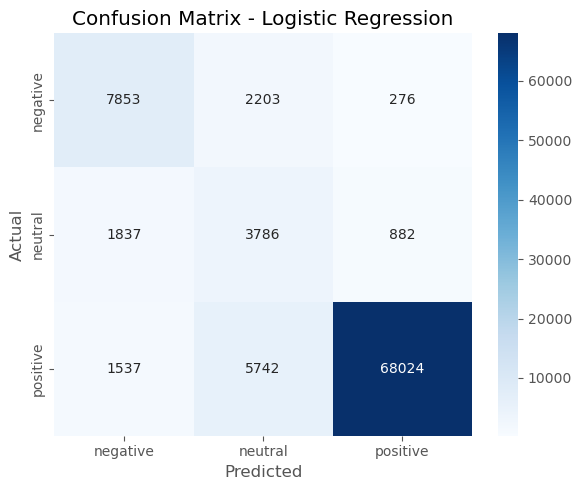

In [13]:
# Plot the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_log_reg,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Logistic Regression: results

Headline metrics: **accuracy 0.86**, **macro F1 0.69**, weighted F1 0.88. Because the dataset is heavily imbalanced (over 80% positive), accuracy overstates the quality — we focus on per-class metrics and macro F1.

Per class:
- **Positive** — precision 0.98, recall 0.90, F1 0.94: the dominant class is recognized confidently.
- **Negative** — precision 0.70, recall 0.75, F1 0.73: most negative reviews are caught, some leak into other classes.
- **Neutral** — precision 0.32, recall 0.60, F1 0.42: the hardest class; 3-star reviews often mix praise and complaints.

The confusion matrix shows that most errors involve the neutral class: the model finds about 60% of neutral reviews but with many false alarms (hence the low precision). Overall, Logistic Regression sets a solid baseline: strong on positive and negative, weak on the ambiguous neutral class.

Основные метрики: **accuracy 0.86**, **macro F1 0.69**, weighted F1 0.88. Из-за сильного дисбаланса (более 80% positive) accuracy завышает качество — смотрим на метрики по классам и macro F1.

По классам:
- **Positive** — precision 0.98, recall 0.90, F1 0.94: доминирующий класс распознаётся уверенно.
- **Negative** — precision 0.70, recall 0.75, F1 0.73: большинство негативных отзывов находится, часть утекает в другие классы.
- **Neutral** — precision 0.32, recall 0.60, F1 0.42: самый сложный класс; отзывы с тремя звёздами часто смешивают похвалу и жалобы.

Матрица ошибок показывает, что основная путаница связана с классом neutral: модель находит около 60% нейтральных отзывов, но с большим числом ложных срабатываний (отсюда низкий precision). В целом Logistic Regression задаёт крепкий базовый уровень: сильна на positive и negative, слаба на неоднозначном neutral.

### Error Analysis

We inspect misclassified reviews to understand typical model errors and label ambiguity.

Разбираем неправильно классифицированные отзывы, чтобы понять типичные ошибки модели и неоднозначность разметки.

In [14]:
# Collect true labels, predictions and texts into one dataframe
error_analysis = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": y_pred_log_reg
})

# Keep only the misclassified rows
errors = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
]

errors.shape


(12477, 3)

In [15]:
# Look at random model errors
errors.sample(
    min(10, len(errors)),
    random_state=42
)

,text,true_label,predicted_label
160701,lovely my harry potter obsessed daughter is over the moon with this set the pictures on the site don t do it justice i accidentally ordered the queen set instead of the twin so i am a bit perplexe...,positive,neutral
335223,had to send back hey if you have dug this deep into the reviews you know you are already going to buy the cadillac of rice cookers congrats that said i will just toss in some data points for you t...,neutral,negative
128456,so its not bad but i expected more i forgot how much they cost me if this item was more then 20 do not purchase it is not worth 20 but over all alot can fit in it i had to air out for a couple of ...,positive,negative
308483,three funnels with filters and brushes can not be nested for storage package comes with 3 different sized funnels all with the same sized exit there is 3 filters that snap in place and 3 brushes f...,positive,neutral
261008,it is pretty but the wood could be a better quality considering the price boy was this sucker a pain in the rump to assemble some of the pre drilled holes were not fully or correctly drilled so we...,positive,neutral
250483,flimsy cooling racks while it s nice that these stack they re really flimsy they re very lightweight and nowhere near as sturdy as other cooling racks they also don t sit completely flat the cente...,negative,neutral
460464,thin and floppy do not trust them to stay solid in the oven these silicone cupcake liners are thin and not easy to use they are squishy and do not look like they could withstand repeated use the p...,negative,neutral
199535,works but has a chemical smell that will not go away this cover does what it is intended to do but unfortunately it has a chemical smell that will not go away no matter what repeated hand washings...,negative,neutral
343348,easy to use quality product easy to use and i did not realize it came with a tiny brush to clean off the filter between use,positive,neutral
359233,great value sturdy cheap and works with headboard i bought this to replace an amazon basics bed frame that cost 12 more it was flimsy and had a headboard mount that was on a swivel and gave the he...,positive,negative


In [16]:
# Errors where the true class is neutral
neutral_errors = errors[
    errors["true_label"] == "neutral"
]

neutral_errors.sample(
    min(10, len(neutral_errors)),
    random_state=42
)

,text,true_label,predicted_label
101518,do not let the photo fool you disappointed that it was not ceramic i thought it was going to be a very nice ceramic spoonrest but it was only plastic,neutral,negative
135979,not the best they are weighted oddly and will fall out of the pot if i rest it in there when i am done cooking also the spatula it already melting on the end after a few uses,neutral,negative
408654,don t be lazy like me and return the set they are beautiful imperfections in several of the plates how ever the non imperfect plates were beautiful one dinner plate has crack under the glaze,neutral,negative
226946,nice chair sucky wheels i like this chair i instantly noticed my posture improved the one down side is the wheels are not that great i can not roll around like i need to so i will probably end up ...,neutral,positive
39620,not worth the money the hour hand on this clock stopped working soon after i bought it,neutral,negative
392486,do not last i got these during the prime days this summer it is been about 3 months and they are already starting to pill they have been pilling for a while now i am not impressed,neutral,negative
148325,replacement hands bought these for my cuckoo clock but they did not fit,neutral,negative
463859,love this chair style but this is the second one that has fallen apart in less than a year i love the style of this chair and the rich wood arms trim and base so much that when the first one fell ...,neutral,negative
74982,does not stand up the has a leg in the back to stand on a table but it falls over since the leg is too short fail avoid,neutral,negative
336402,fits my large bags this one works well i love that it is individual boxes so you can move them around your draw cabinet to fit properly however i do not like that the vehhe brand is boldly emblazo...,neutral,positive


In [17]:
# Errors where the true class is negative
negative_errors = errors[
    errors["true_label"] == "negative"
]

negative_errors.sample(
    min(10, len(negative_errors)),
    random_state=42
)

,text,true_label,predicted_label
355490,good price but not durable enough i was hoping for both a bargain and easy to assemble and maintain product man o man was i wrong great price if you like a product that collapses way tooo easily i...,negative,neutral
315594,tiny opening these are cute but so tiny it takes a bit of effort to drink a frozen drink we ll use them but i won t buy again,negative,neutral
185101,on sign received thankful is misspelled thankfhl sign is very cute but sadly the thanksgiving word thankful is misspelled as thankfhl sad it is a mistake will need to find a different sign,negative,neutral
422113,it s ok it doesn t humidify as well as i expected but it does help,negative,neutral
255151,fixing eggs with out a mess it is hard to understand the instructions well made item,negative,positive
338458,i guess i missed it in the description this suitcase does not close i ended up buying my grandson another one because this style was useless to him,negative,neutral
406614,ok quality but just ok this platter looks nice but it has some obvious quality issues i can clearly see the silkscreen pattern in the ink which makes me think that these are not the ones sold in r...,negative,neutral
242835,leaky leaks from the bottom but blends nicely,negative,positive
200547,hands free can opener i really do not like this opener it does not work on all cans i hardly ever use it my old one was perfect but after years of use it finally broke down,negative,neutral
105990,pass on this one replaced the thermopile in my fireplace with this worked 2x and now the millivolts reading is under 100 when i check it can t someone make one of these that works,negative,positive


In [18]:
# Most confident predictions
predictions_df.sort_values(
    "confidence",
    ascending=False
).head(10)

,text,true_label,predicted_label,confidence
78599,excellent hooks highly recommend sturdy and easy to install great value thank you,positive,positive,1.000000
71874,perfect absolutely love it,positive,positive,0.999999
17681,definitely what do recommend love this product oh my god i love this organizer i am about to buy 5 more of them in white for my kids rooms i love them they are amazing they are super sturdy and th...,positive,positive,0.999998
73067,love i love it is perfect,positive,positive,0.999998
38041,amazing what a fantastic christmas pillow great quality velvet very soft looks great amazing quality for such a low price very happy highly recommend,positive,positive,0.999997
13865,love it i love this it is perfect,positive,positive,0.999997
51786,absolutely amazing excellent i love it,positive,positive,0.999997
55052,love it this works perfectly i absolutely love it,positive,positive,0.999997
8193,excellent great value i highly recommend these colorful bowls,positive,positive,0.999997
23181,perfect for griller s great quality and so easy to use happy with them,positive,positive,0.999997


In [19]:
# Least confident predictions
predictions_df.sort_values(
    "confidence",
    ascending=True
).head(10)

,text,true_label,predicted_label,confidence
41769,not easy to clean it has picked up so many stains after thanksgiving had to steam it to get most of the wrinkles out the colors are beautiful but i am getting a clear table cloth to go over it so ...,neutral,positive,0.335675
24712,messy because lid and mechanism are attached i found this frother required precise lining up of the cup to base i also found it to be a messy frother because the mechanism is attached to the lid i...,neutral,positive,0.336346
43821,clean efficient egg separator the delightly egg yolk white separator is a great little kitchen gadget it separates the yolk from the whites easily completely you simply crack an egg into the the b...,positive,neutral,0.338940
65301,as advertised i needed to steam them to remove the wrinkles but this was a small price to pay for the quality they do not totally black out a room but the degree of blockage keeps the room suffici...,positive,positive,0.339495
42821,no longer does my wife loose the remote so its 3 am tv is still on and i can not find the remote not now now it is in the pouch next to her reading glasses and tv watching glasses,positive,positive,0.340230
13465,one night once they got wet the broke for one night use they are great looking,negative,neutral,0.341175
78108,best contigo coffee travel mug i purchased another type of continuo mug with just a snap seal i highly recommend this one over that one the one with the snap seal leaks after 4 months the gasket d...,positive,negative,0.341911
15994,strange engineering the popper produces a lot of popcorn per batch you will need a giant bowl to catch it all the manufacturer recommends waiting about 10 minutes between each batch though to pres...,positive,negative,0.342523
54000,arrived dirty so cute and a great price but arrived with these small specs in the bag another review which i noticed after i bought mentioned it s dirt pretty gross,negative,neutral,0.342759
8236,navy they worked out not as navy as i wanted,positive,negative,0.342930


In [20]:
# Most confident errors
confident_errors = predictions_df[
    predictions_df["true_label"] !=
    predictions_df["predicted_label"]
]

confident_errors.sort_values(
    "confidence",
    ascending=False
).head(10)

,text,true_label,predicted_label,confidence
22104,great value versatile love them versatile,neutral,positive,0.999943
54783,perfect perfect for what i needed,negative,positive,0.999724
62594,love it beautiful just what i expected,negative,positive,0.999629
17034,labeling all my new storage containers these are great totally happy with them,neutral,positive,0.999563
19928,k cup holder i love it it was exactly what i was looking for holds a great amount of k cups,neutral,positive,0.999358
80798,super nice very nice highly recommend it is nice and deep fits perfect as my mattress is super high took to ling to get here tho,neutral,positive,0.998233
26228,great buy great knives super sharp,neutral,positive,0.998220
36486,i love it i love it haven t had any problems since it came outa the box it s a little slow but that s to be expected other than that it works great for the kids in my building,neutral,positive,0.998177
24056,not even water resistant the product is not even liquid resistant at all very disappointed,positive,negative,0.997616
57709,cheap chinese junk this is cheap chinese junk that americans are paying too dollars for,neutral,negative,0.996975


Confidence analysis shows the model is most certain about typical positive reviews: phrases like `works great`, `highly recommend`, `great quality` get confidence close to 1.0. The least certain predictions are long, mixed reviews that combine praise and complaints.

The neutral class is the hardest: many 3-star reviews contain clearly emotional words (`perfect`, `love`, `disappointed`), so the model assigns them to positive or negative. High-confidence errors (`love them versatile`, `returned product disappointed`) follow the same pattern: the model reads the sentiment words, while the "true" label comes from the star rating.

Key takeaway: many errors come from the data, not the model. Labels are derived from ratings (weak supervision), and the rating does not always match the actual tone of the text.

Анализ уверенности показывает, что модель наиболее уверена в типичных позитивных отзывах: фразы вида `works great`, `highly recommend`, `great quality` получают уверенность около 1.0. Наименее уверенные предсказания — длинные смешанные отзывы, где похвала соседствует с жалобами.

Класс neutral самый трудный: многие отзывы с тремя звёздами содержат явно эмоциональные слова (`perfect`, `love`, `disappointed`), и модель относит их к positive или negative. Уверенные ошибки (`love them versatile`, `returned product disappointed`) устроены так же: модель читает эмоциональные слова, а «истинная» метка взята из рейтинга.

Главный вывод: значительная часть ошибок идёт от данных, а не от модели. Разметка получена из рейтингов (weak supervision), а рейтинг не всегда совпадает с реальной тональностью текста.

### Baseline Model 2: LinearSVC

We train the second baseline on the same TF-IDF features. LinearSVC has no probability output, so we wrap it in `CalibratedClassifierCV` — this adds `predict_proba`, which we need for confidence and mismatch analysis.

Обучаем вторую базовую модель на тех же TF-IDF признаках. LinearSVC не выдаёт вероятности, поэтому оборачиваем его в `CalibratedClassifierCV` — это добавляет `predict_proba`, нужный для анализа уверенности и расхождений.

In [21]:
# Path to the saved model
svc_model_path = "models/svc_pipeline.joblib"

# Build the pipeline: TF-IDF -> calibrated LinearSVC
# LinearSVC has no probability output, so we wrap it in
# CalibratedClassifierCV: this adds predict_proba (confidence scores)
# used in the error and mismatch analysis, and makes SVC a single
# model for both analysis and deployment.
# Each model trains inside its own pipeline to avoid data leakage.

pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", CalibratedClassifierCV(
        LinearSVC(
            class_weight="balanced",
            random_state=42
        ),
        method="sigmoid",
        cv=3
    ))
])

# Load the model if it already exists
if os.path.exists(svc_model_path):

    pipe_svc = joblib.load(
        svc_model_path
    )

    print("LinearSVC model loaded")

# Otherwise train and save
else:

    pipe_svc.fit(X_train, y_train)

    joblib.dump(
        pipe_svc,
        svc_model_path
    )

    print("LinearSVC model trained and saved")

LinearSVC model loaded


/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using ve

In [22]:
# LinearSVC predictions on the test set
y_pred_svc = pipe_svc.predict(X_test)

In [23]:
# Evaluate LinearSVC
print(classification_report(y_test, y_pred_svc))


              precision    recall  f1-score   support

    negative       0.75      0.77      0.76     10332
     neutral       0.49      0.17      0.26      6505
    positive       0.93      0.98      0.96     75303

    accuracy                           0.90     92140
   macro avg       0.72      0.64      0.66     92140
weighted avg       0.88      0.90      0.89     92140



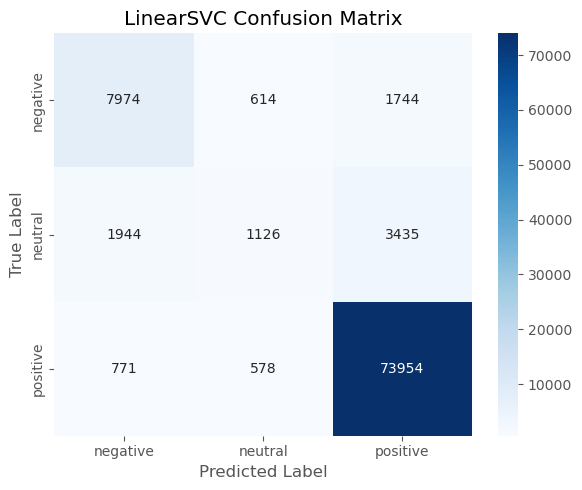

In [24]:
# Confusion matrix for LinearSVC
cm_svc = confusion_matrix(
    y_test,
    y_pred_svc
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipe_svc.classes_,
    yticklabels=pipe_svc.classes_
)

plt.title("LinearSVC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### LinearSVC: results

Headline metrics: **accuracy 0.90**, macro F1 0.66, **weighted F1 0.89** — the best accuracy and weighted F1 among the baselines, achieved at the expense of the neutral class.

Per class:
- **Positive** — precision 0.93, recall 0.98, F1 0.96: nearly flawless on the dominant class.
- **Negative** — precision 0.75, recall 0.77, F1 0.76: slightly better than Logistic Regression.
- **Neutral** — precision 0.49, recall 0.17, F1 0.26: the model almost stops finding neutral reviews.

Compared to Logistic Regression, LinearSVC is much more conservative with the neutral label: precision rose (0.32 → 0.49) but recall collapsed (0.60 → 0.17) — borderline reviews go to positive or negative instead. So LinearSVC maximizes overall accuracy and quality on the major classes, but misses most truly neutral reviews, which lowers its macro F1.

Основные метрики: **accuracy 0.90**, macro F1 0.66, **weighted F1 0.89** — лучшие accuracy и weighted F1 среди базовых моделей, но ценой класса neutral.

По классам:
- **Positive** — precision 0.93, recall 0.98, F1 0.96: почти безошибочно на доминирующем классе.
- **Negative** — precision 0.75, recall 0.77, F1 0.76: немного лучше Logistic Regression.
- **Neutral** — precision 0.49, recall 0.17, F1 0.26: модель почти перестаёт находить нейтральные отзывы.

По сравнению с Logistic Regression модель гораздо осторожнее с меткой neutral: precision вырос (0.32 → 0.49), но recall обвалился (0.60 → 0.17) — спорные отзывы уходят в positive или negative. Итого LinearSVC максимизирует общую точность и качество на крупных классах, но пропускает большинство действительно нейтральных отзывов, что снижает macro F1.

### Baseline Model 3: LightGBM

We add a gradient boosting model as a non-linear baseline, to check whether a more complex model beats linear ones on sparse TF-IDF features.

Добавляем градиентный бустинг как нелинейную базовую модель — проверяем, обойдёт ли более сложная модель линейные на разреженных TF-IDF признаках.

In [25]:
# Path to the saved model
lgbm_model_path = "models/lightgbm_pipeline.joblib"

# Build the pipeline: TF-IDF → LightGBM
# Each model trains inside its own pipeline to avoid data leakage

pipe_lgbm = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf", LGBMClassifier(
        class_weight="balanced",
        n_estimators=300,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# Load the model if it already exists
if os.path.exists(lgbm_model_path):

    pipe_lgbm = joblib.load(
        lgbm_model_path
    )

    print("LightGBM model loaded")

# Otherwise train and save
else:

    pipe_lgbm.fit(X_train, y_train)

    joblib.dump(
        pipe_lgbm,
        lgbm_model_path
    )

    print("LightGBM model trained and saved")

LightGBM model loaded


/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using

In [26]:
# LightGBM predictions on the test set
y_pred_lgbm = pipe_lgbm.predict(X_test)

/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
# Evaluate LightGBM per class
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

    negative       0.71      0.75      0.73     10332
     neutral       0.32      0.62      0.42      6505
    positive       0.98      0.89      0.94     75303

    accuracy                           0.86     92140
   macro avg       0.67      0.76      0.70     92140
weighted avg       0.91      0.86      0.88     92140



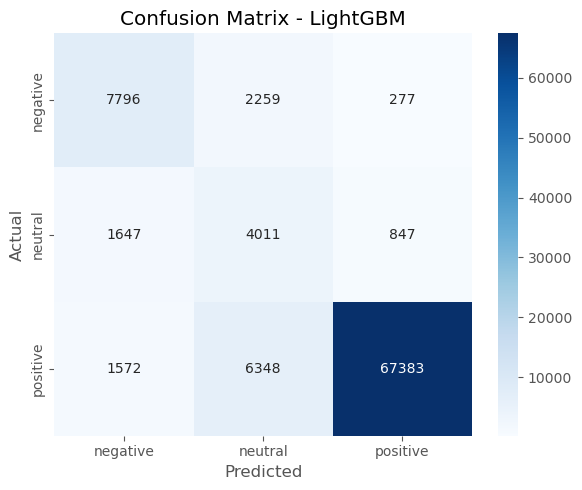

In [28]:
# Plot the confusion matrix for LightGBM
cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### LightGBM: results

Headline metrics: accuracy 0.86, **macro F1 0.70** (the best among the baselines), weighted F1 0.88.

Per class:
- **Positive** — precision 0.98, recall 0.89, F1 0.94: confident, recall slightly below LinearSVC.
- **Negative** — precision 0.71, recall 0.75, F1 0.73: on par with Logistic Regression.
- **Neutral** — precision 0.32, recall 0.62, F1 0.42: the best neutral recall among the three models, at the cost of many false alarms.

Unlike LinearSVC, LightGBM actively predicts the neutral class and finds over 60% of such reviews. The result is the most balanced quality across all three classes — but no advantage in accuracy, and a non-linear model shows no edge over linear ones on sparse TF-IDF features (a common outcome).

Основные метрики: accuracy 0.86, **macro F1 0.70** (лучший среди базовых моделей), weighted F1 0.88.

По классам:
- **Positive** — precision 0.98, recall 0.89, F1 0.94: уверенно, recall чуть ниже, чем у LinearSVC.
- **Negative** — precision 0.71, recall 0.75, F1 0.73: на уровне Logistic Regression.
- **Neutral** — precision 0.32, recall 0.62, F1 0.42: лучший recall на neutral среди трёх моделей, ценой множества ложных срабатываний.

В отличие от LinearSVC, LightGBM активно предсказывает класс neutral и находит более 60% таких отзывов. В итоге — самое ровное качество по всем трём классам, но без преимущества по accuracy; нелинейная модель не выигрывает у линейных на разреженных TF-IDF признаках (типичная ситуация).

### Baseline comparison

A summary table of Logistic Regression, LinearSVC and LightGBM metrics.

Сводная таблица метрик Logistic Regression, LinearSVC и LightGBM.

In [29]:
# Compare models by key metrics
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "LinearSVC",
        "LightGBM"
    ],
    "accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "macro_f1": [
        f1_score(y_test, y_pred_log_reg, average="macro"),
        f1_score(y_test, y_pred_svc, average="macro"),
        f1_score(y_test, y_pred_lgbm, average="macro")
    ],
    "weighted_f1": [
        f1_score(y_test, y_pred_log_reg, average="weighted"),
        f1_score(y_test, y_pred_svc, average="weighted"),
        f1_score(y_test, y_pred_lgbm, average="weighted")
    ]
})

model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.864586,0.695114,0.880549
1,LinearSVC,0.901389,0.657214,0.885814
2,LightGBM,0.859453,0.695671,0.877390


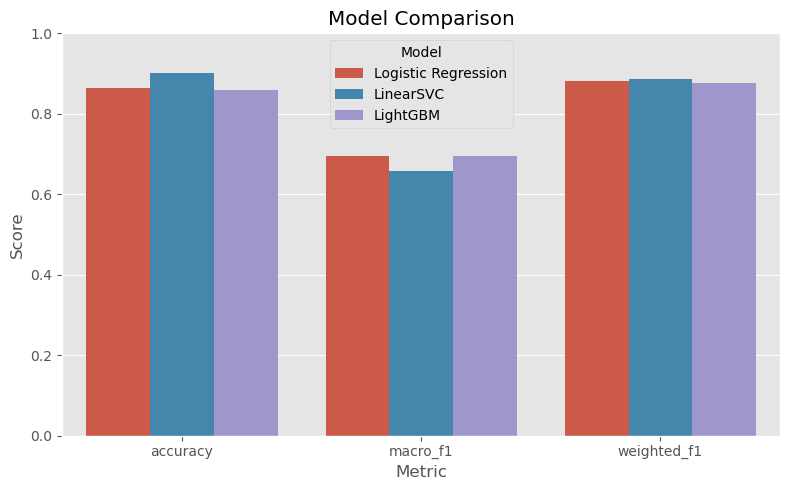

In [30]:
# Visualize model comparison
model_comparison_melted = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison_melted,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

#### Baseline comparison: conclusion

| Model | Accuracy | Macro F1 | Weighted F1 |
|----------|----------|----------|----------|
| Logistic Regression | 0.862 | 0.694 | 0.879 |
| LinearSVC (calibrated) | **0.901** | 0.657 | **0.886** |
| LightGBM | 0.859 | **0.696** | 0.877 |

Which model is "best" depends on the metric. LinearSVC clearly leads on accuracy and weighted F1 thanks to its quality on the dominant positive class. By macro F1, which treats all classes equally, LightGBM (0.696) and Logistic Regression (0.694) are nearly tied and well above LinearSVC (0.657). The whole difference comes from the neutral class: the first two keep finding neutral reviews, LinearSVC mostly does not.

We choose **LinearSVC** as the final baseline: the best overall accuracy (0.901) and weighted F1 (0.886), fast training and prediction on sparse features, and calibrated probabilities for confidence analysis. The known trade-off is the low neutral recall; where equal quality across classes matters more, Logistic Regression or LightGBM would be preferable.

Notably, LightGBM as a non-linear model showed no advantage over linear ones — typical for high-dimensional sparse TF-IDF features, where linear methods are often both faster and stronger.

Какая модель «лучшая» — зависит от метрики. LinearSVC уверенно лидирует по accuracy и weighted F1 за счёт качества на доминирующем классе positive. По macro F1, где все классы равны, LightGBM (0.696) и Logistic Regression (0.694) почти равны и заметно опережают LinearSVC (0.657). Вся разница — в классе neutral: первые две модели продолжают его находить, LinearSVC — почти нет.

Финальной базовой моделью выбираем **LinearSVC**: лучшая общая точность (0.901) и weighted F1 (0.886), быстрое обучение и предсказание на разреженных признаках, плюс калиброванные вероятности для анализа уверенности. Известный компромисс — низкий recall на neutral; там, где важно равное качество по всем классам, предпочтительнее Logistic Regression или LightGBM.

Показательно, что LightGBM как нелинейная модель не дала преимущества над линейными — это типично для разреженных TF-IDF признаков высокой размерности, где линейные методы часто и быстрее, и сильнее.

## 2.2 Deployment

The final model is assembled as an end-to-end pipeline: raw text → cleaning → calibrated LinearSVC → sentiment. The cleaning step is built into the pipeline itself, so the model accepts an unprocessed review (with HTML and contractions) and prepares it exactly as during training — train and inference preprocessing cannot drift apart.

The model is saved to `models/final_sentiment_model.joblib`, loaded back and checked on raw examples (one positive, one negative) — both predictions are correct.

Финальная модель собирается как единый пайплайн: сырой текст → очистка → калиброванный LinearSVC → тональность. Шаг очистки встроен в сам пайплайн, поэтому модель принимает необработанный отзыв (с HTML и сокращениями) и готовит его ровно так же, как при обучении — предобработка при обучении и при использовании не может разойтись.

Модель сохраняется в `models/final_sentiment_model.joblib`, загружается обратно и проверяется на сырых примерах (позитивном и негативном) — оба предсказания верны.

In [31]:
# Final deployment model: wrap the trained pipe_svc in a pipeline
# with a text-cleaning step, so the model accepts RAW text (HTML, contractions, etc.)
# This rules out any drift between training-time and inference-time preprocessing.
# clean_batch is imported from nlp_utils, so the pickle references an importable
# module (nlp_utils.clean_batch) instead of __main__ — no unpickling hacks needed.

final_sentiment_model = Pipeline([
    ("clean", FunctionTransformer(clean_batch, validate=False)),
    ("model", pipe_svc),
])

joblib.dump(
    final_sentiment_model,
    "models/final_sentiment_model.joblib"
)

print("Final model saved (end-to-end: raw text -> sentiment)")

Final model saved (end-to-end: raw text -> sentiment)


In [32]:
# Load the saved model
loaded_model = joblib.load(
    "models/final_sentiment_model.joblib"
)

print("Model loaded successfully")

Model loaded successfully


In [33]:
# Example prediction on RAW text (with HTML and contractions)
sample_review = "The product <b>looks great</b> and it's very easy to use!!! https://amazon.com"

prediction = loaded_model.predict([sample_review])

print(f"Predicted sentiment: {prediction[0]}")


Predicted sentiment: positive


In [34]:
# Example negative review with contractions and HTML
negative_review = "The product stopped working after two days and doesn't feel sturdy. I can't recommend it."

negative_prediction = loaded_model.predict([negative_review])

print(f"Negative review prediction: {negative_prediction[0]}")


Negative review prediction: negative


## 2.3 LinearSVC Hyperparameter Tuning

LinearSVC was chosen as the final baseline, so the next step is to tune it with `RandomizedSearchCV`. We optimize macro F1 (the right metric for imbalanced data) and search over both the model parameter `C` and the TF-IDF settings, using 3-fold cross-validation on the training set only. The best model is saved to disk and reloaded on later runs.

LinearSVC выбран финальной базовой моделью, поэтому следующий шаг — подбор гиперпараметров через `RandomizedSearchCV`. Оптимизируем macro F1 (правильная метрика для несбалансированных данных), перебираем и параметр модели `C`, и настройки TF-IDF; оценка — кросс-валидация на 3 блока только по обучающей выборке. Лучшая модель сохраняется на диск и при следующих запусках загружается.

Tuned LinearSVC loaded


/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mchunikhin/miniconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using ve

              precision    recall  f1-score   support

    negative      0.735     0.785     0.759     10332
     neutral      0.407     0.464     0.434      6505
    positive      0.969     0.948     0.959     75303

    accuracy                          0.896     92140
   macro avg      0.704     0.732     0.717     92140
weighted avg      0.903     0.896     0.899     92140



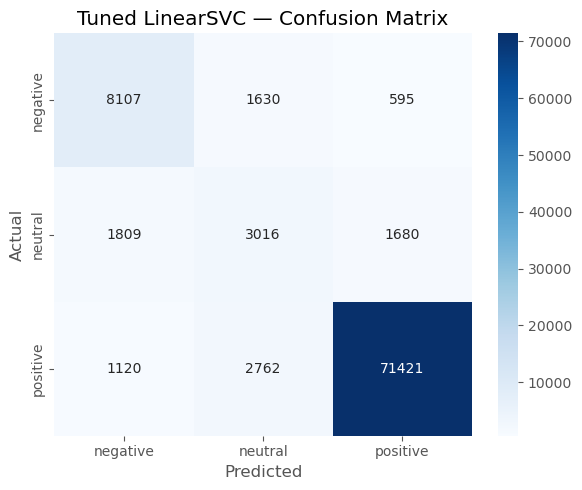

In [35]:
# Hyperparameter search for LinearSVC and TF-IDF by macro-F1
svc_tuned_path = "models/svc_tuned_pipeline.joblib"

# Same input and split as the baselines: X_train / X_test = clean_text.
pipe_tuned = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LinearSVC(class_weight="balanced", random_state=42)),
    ]
)

if os.path.exists(svc_tuned_path):
    pipe_tuned = joblib.load(svc_tuned_path)
    print("Tuned LinearSVC loaded")
else:
    param_dist = {
        "tfidf__max_features": [20000, 50000, 100000],
        "tfidf__min_df": [2, 5, 10],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "clf__C": loguniform(1e-2, 1e1),
    }
    search = RandomizedSearchCV(
        pipe_tuned,
        param_dist,
        n_iter=15,
        scoring="f1_macro",
        cv=3,
        n_jobs=4,
        random_state=42,
        verbose=1,
    )
    search.fit(X_train, y_train)
    print("Best params:", search.best_params_)
    print("Best CV macro-F1:", round(search.best_score_, 4))

    # Refit the best configuration on the FULL train set.
    pipe_tuned = Pipeline(
        [
            ("tfidf", TfidfVectorizer()),
            ("clf", LinearSVC(class_weight="balanced", random_state=42)),
        ]
    ).set_params(**search.best_params_)
    pipe_tuned.fit(X_train, y_train)
    joblib.dump(pipe_tuned, svc_tuned_path)
    print("Tuned LinearSVC trained and saved")

# Evaluate on the test set
y_pred_tuned = pipe_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned, digits=3))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"],
)
plt.title("Tuned LinearSVC — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Tuning results

| LinearSVC | Accuracy | Macro F1 | Weighted F1 | Recall (neutral) |
|---|---|---|---|---|
| Default (`C=1.0`) | 0.901 | 0.657 | 0.886 | 0.170 |
| **Tuned** (`C≈0.06`, TF-IDF 50k, uni+bi) | 0.896 | **0.717** | **0.899** | **0.464** |

Tuning improved the model substantially. Accuracy dipped slightly (0.901 → 0.896), but macro F1 rose from 0.657 to 0.717 and neutral recall almost tripled (0.17 → 0.46) — the main weakness of the default LinearSVC is largely fixed.

The key factor is regularization: the best `C ≈ 0.06` is much smaller than the default 1.0. Stronger regularization combined with `class_weight="balanced"` makes the model pay more attention to the rare classes instead of leaning towards positive. The small accuracy loss is an expected and acceptable trade-off on imbalanced data.

Conclusion: a classic linear model has much more headroom than its default settings suggest. With macro F1 = 0.717 the tuned LinearSVC becomes the strongest baseline and the reference point for the transformer experiment that follows.

Подбор существенно улучшил модель. Accuracy немного снизилась (0.901 → 0.896), зато macro F1 вырос с 0.657 до 0.717, а recall класса neutral почти утроился (0.17 → 0.46) — главный недостаток LinearSVC по умолчанию в основном устранён.

Ключевой фактор — регуляризация: лучшее `C ≈ 0.06` намного меньше стандартного 1.0. Более сильная регуляризация вместе с `class_weight="balanced"` заставляет модель уделять больше внимания редким классам, а не тяготеть к positive. Небольшая потеря accuracy — ожидаемый и приемлемый компромисс на несбалансированных данных.

Вывод: у классической линейной модели запас качества заметно больше, чем кажется по настройкам по умолчанию. С macro F1 = 0.717 настроенный LinearSVC становится сильнейшей базовой моделью и точкой отсчёта для следующего эксперимента с трансформером.

## 2.4 Experiment: Transformer (DistilBERT)

TF-IDF models share one fundamental limitation: they see a bag of words and ignore sentence context. This hurts most on the neutral class. In this experiment we check whether a context-aware transformer (DistilBERT) beats the classic baseline.

The comparison is fair: the same train/test split (`random_state=42`, stratified), the same labeling scheme, the same test set. Key differences of DistilBERT: it reads the raw text (`title + text`) instead of TF-IDF, uses a class-weighted loss to counter the ~82/11/7 imbalance, and trains on GPU with mixed precision (fp16).

> The heavy training runs in the cell below (RTX 3090, fp16, 2 epochs). The notebook loads the saved model from `models/distilbert_sentiment/` if it exists, otherwise it fine-tunes automatically.

У TF-IDF-моделей одно принципиальное ограничение: они видят набор слов и не учитывают контекст предложения. Сильнее всего это бьёт по классу neutral. В этом эксперименте проверяем, обойдёт ли контекстный трансформер (DistilBERT) классический baseline.

Сравнение честное: то же разбиение train/test (`random_state=42`, со стратификацией), та же схема разметки, та же тестовая выборка. Ключевые отличия DistilBERT: читает сырой текст (`title + text`) вместо TF-IDF, использует взвешенный loss против дисбаланса ~82/11/7 и обучается на GPU со смешанной точностью (fp16).

> Тяжёлое обучение выполняется в ячейке ниже (RTX 3090, fp16, 2 эпохи). Если сохранённая модель есть в `models/distilbert_sentiment/`, ноутбук загружает её, иначе дообучает автоматически.

In [36]:
# Fine-tune DistilBERT on the same split and labels as the baselines
DISTILBERT_DIR = "models/distilbert_sentiment"
MODEL_NAME = "distilbert-base-uncased"
LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID2LABEL = {i: lbl for lbl, i in LABEL2ID.items()}

print("CUDA available:", torch.cuda.is_available())

# Reuse EXACTLY the same split as the baselines: X_train/X_test come from
# train_test_split(random_state=42, stratify). We take the raw text (title + text)
# for the same rows — DistilBERT has its own tokenizer; case and punctuation help.
def raw_text(index):
    return (
        reviews.loc[index, "title"].fillna("").astype(str)
        + ". "
        + reviews.loc[index, "text"].fillna("").astype(str)
    ).tolist()


train_texts = raw_text(X_train.index)
test_texts = raw_text(X_test.index)
train_labels = y_train.map(LABEL2ID).tolist()
test_labels = y_test.map(LABEL2ID).tolist()

tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_DIR if os.path.exists(DISTILBERT_DIR) else MODEL_NAME
)


def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)


test_ds = Dataset.from_dict({"text": test_texts, "label": test_labels}).map(
    tokenize, batched=True, remove_columns=["text"]
)

# Class-weighted loss (inverse frequency) to counter the imbalance and help neutral.
counts = np.bincount(train_labels, minlength=3)
class_weights = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights.to(outputs.logits.device)
        )
        return (loss, outputs) if return_outputs else loss


if os.path.exists(DISTILBERT_DIR):
    distilbert = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_DIR)
    print("Loaded fine-tuned DistilBERT from", DISTILBERT_DIR)
else:
    train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(
        tokenize, batched=True, remove_columns=["text"]
    )
    distilbert = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    )
    args = TrainingArguments(
        output_dir=DISTILBERT_DIR,
        num_train_epochs=2,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=128,
        learning_rate=2e-5,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
    )
    trainer = WeightedTrainer(
        model=distilbert,
        args=args,
        train_dataset=train_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
    )
    trainer.train()
    distilbert.save_pretrained(DISTILBERT_DIR)
    tokenizer.save_pretrained(DISTILBERT_DIR)
    print("Fine-tuned and saved DistilBERT ->", DISTILBERT_DIR)


CUDA available: True


Map:   0%|          | 0/92140 [00:00<?, ? examples/s]

Loaded fine-tuned DistilBERT from models/distilbert_sentiment


/tmp/ipykernel_34129/2467442557.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  eval_trainer = Trainer(


              precision    recall  f1-score   support

    negative      0.805     0.782     0.793     10332
     neutral      0.375     0.692     0.486      6505
    positive      0.990     0.921     0.954     75303

    accuracy                          0.889     92140
   macro avg      0.723     0.798     0.744     92140
weighted avg      0.926     0.889     0.903     92140

accuracy=0.889  macro_f1=0.744  weighted_f1=0.903


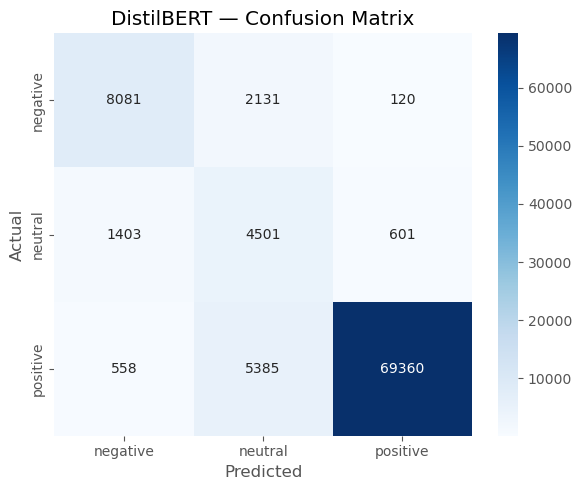

In [37]:
# Evaluate DistilBERT on the test set
eval_args = TrainingArguments(
    output_dir=DISTILBERT_DIR,
    per_device_eval_batch_size=128,
    fp16=torch.cuda.is_available(),
    report_to="none",
)
eval_trainer = Trainer(
    model=distilbert,
    args=eval_args,
    data_collator=DataCollatorWithPadding(tokenizer),
    tokenizer=tokenizer,
)

pred = eval_trainer.predict(test_ds)
y_pred_bert = pred.predictions.argmax(-1)
y_true_bert = np.array(test_labels)

print(classification_report(y_true_bert, y_pred_bert, target_names=LABELS, digits=3))
print(
    f"accuracy={accuracy_score(y_true_bert, y_pred_bert):.3f}  "
    f"macro_f1={f1_score(y_true_bert, y_pred_bert, average='macro'):.3f}  "
    f"weighted_f1={f1_score(y_true_bert, y_pred_bert, average='weighted'):.3f}"
)

# Confusion matrix
cm = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS
)
plt.title("DistilBERT — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### Truncation check (max_length=128)

DistilBERT reads at most 128 tokens per review; longer reviews are cut off. Here we measure how many test reviews actually exceed that limit, to show what the truncation costs.

DistilBERT читает максимум 128 токенов на отзыв; более длинные обрезаются. Здесь измеряем, сколько отзывов в тесте реально длиннее лимита, чтобы показать цену обрезки.

In [38]:
# How many test reviews exceed the 128-token limit used by DistilBERT
token_lens = np.array([len(ids) for ids in tokenizer(test_texts, truncation=False)["input_ids"]])
share_truncated = (token_lens > 128).mean() * 100

print(f"Reviews longer than 128 tokens: {share_truncated:.1f}% of the test set")
print(f"Median length: {np.median(token_lens):.0f} tokens, "
      f"95th percentile: {np.percentile(token_lens, 95):.0f} tokens")

Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors


Reviews longer than 128 tokens: 11.9% of the test set
Median length: 44 tokens, 95th percentile: 198 tokens


### All models compared: final conclusion

All models are evaluated on the same test set (92,140 reviews, split with `random_state=42`).

| Model | accuracy | macro F1 | weighted F1 | recall (neutral) |
|---|---|---|---|---|
| Logistic Regression | 0.862 | 0.694 | 0.879 | 0.60 |
| LinearSVC (default) | 0.901 | 0.657 | 0.886 | 0.17 |
| LightGBM | 0.859 | 0.696 | 0.877 | 0.62 |
| LinearSVC (tuned) | 0.896 | 0.717 | 0.899 | 0.464 |
| **DistilBERT (fine-tuned)** | 0.889 | **0.744** | **0.903** | **0.692** |

On imbalanced data (~82% positive) accuracy says little, so the key metrics are macro F1 and neutral recall — the hardest class.

- **DistilBERT wins on both key metrics:** macro F1 0.744 vs 0.717 for the tuned baseline, weighted F1 0.903 — also the best.
- **The biggest gap is on neutral:** recall 0.69 vs 0.46 (tuned) and 0.17 (default). DistilBERT finds about two thirds of neutral reviews, which the baselines mostly missed.
- The price is a slightly lower accuracy (0.889) and modest neutral precision (0.375): the weighted loss makes the model predict neutral more often — a justified trade on an imbalanced task.

Overall conclusion: careful tuning makes the classic baseline much stronger, but a model that understands word order and context still wins. The limitation of TF-IDF models is the text representation itself — word and bigram counts cannot capture the meaning of a whole sentence.

Все модели оценены на одной тестовой выборке (92 140 отзывов, разбиение с `random_state=42`).

На несбалансированных данных (~82% positive) accuracy малоинформативна, поэтому ключевые метрики — macro F1 и recall класса neutral, самого трудного.

- **DistilBERT выигрывает по обеим ключевым метрикам:** macro F1 0.744 против 0.717 у настроенного baseline; weighted F1 0.903 — тоже лучший.
- **Самый большой отрыв — на классе neutral:** recall 0.69 против 0.46 (после подбора) и 0.17 (по умолчанию). DistilBERT находит около двух третей нейтральных отзывов, которые базовые модели в основном пропускали.
- Цена — немного меньшая accuracy (0.889) и скромный precision на neutral (0.375): взвешенный loss заставляет модель чаще предсказывать neutral; на несбалансированной задаче это оправданный обмен.

Общий вывод: аккуратный подбор гиперпараметров заметно усиливает классический baseline, но модель, понимающая порядок слов и контекст, всё равно впереди. Ограничение TF-IDF-моделей — само представление текста: частоты слов и биграмм не передают смысл предложения целиком.

### Statistical significance of the DistilBERT advantage (bootstrap)

Is the macro-F1 gap (0.744 vs 0.717) real or noise? McNemar's test is not the right tool here: it compares accuracy, where the two models intentionally trade off. Our target metric is macro-F1, so we bootstrap its difference: resample the test set 1,000 times and look at the distribution of the macro-F1 gap. If the 95% confidence interval stays above zero, the advantage is statistically significant.

Реален ли разрыв по macro-F1 (0.744 против 0.717) или это шум? Тест Макнемара здесь не подходит: он сравнивает accuracy, по которой модели осознанно разменялись. Наша целевая метрика — macro-F1, поэтому используем bootstrap: пересэмплируем тестовую выборку 1000 раз и смотрим на распределение разницы macro-F1. Если 95%-й доверительный интервал не задевает ноль — преимущество статистически значимо.

In [39]:
# Bootstrap the macro-F1 difference between DistilBERT and the tuned LinearSVC
# on the same test set (1,000 resamples with replacement)
rng = np.random.default_rng(42)
y_true_arr = y_test.to_numpy()
pred_tuned = np.asarray(y_pred_tuned)
pred_bert = np.array([ID2LABEL[i] for i in y_pred_bert])

n = len(y_true_arr)
B = 1000
diffs = np.empty(B)
for i in range(B):
    idx = rng.integers(0, n, n)
    diffs[i] = (
        f1_score(y_true_arr[idx], pred_bert[idx], average="macro")
        - f1_score(y_true_arr[idx], pred_tuned[idx], average="macro")
    )

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
share_no_gain = (diffs <= 0).mean()

print(f"macro-F1 difference (DistilBERT - tuned LinearSVC): {diffs.mean():+.4f}")
print(f"95% bootstrap CI: [{ci_low:+.4f}, {ci_high:+.4f}]")
print(f"Bootstrap samples with no advantage: {share_no_gain:.4f}"
      + (" -> p < 0.001, the advantage is statistically significant" if share_no_gain < 0.001 else ""))

macro-F1 difference (DistilBERT - tuned LinearSVC): +0.0275
95% bootstrap CI: [+0.0234, +0.0320]
Bootstrap samples with no advantage: 0.0000 -> p < 0.001, the advantage is statistically significant
